In [1]:
import numpy as np
import discretize
from discretize.utils import mesh_utils
import matplotlib.pyplot as plt

In [2]:
# 1) Malla

base_xy = 250.0
hx = mesh_utils.unpack_widths([(base_xy, 5, -1.3), (base_xy, 4), (base_xy, 5, 1.3)])
hy = hx.copy()

base_z = 150.0
hz = mesh_utils.unpack_widths([(base_z, 6, -1.3), (base_z, 10), (base_z, 6, 1.3)])

mesh = discretize.TensorMesh(
    [hx, hy, hz],
    x0=[-np.sum(hx) / 2, -np.sum(hy) / 2, -np.sum(hz[:10])]
)

# 2) Modelo 2D de conductividad
sigma = 1e-2 * np.ones(mesh.nC)
cc = mesh.cell_centers
x = cc[:, 0]
y = cc[:, 1]
z = cc[:, 2]

anomaly = (
    (x > -500) & (x < 500) &
    (z < -200) & (z > -600)
)
sigma[anomaly] = 1e-1
sigma[z > 0] = 1e-8  # air

print("mesh =", mesh)
print("mesh.nC=", mesh.nC)
print("mesh.nEx=", mesh.nEx)
print("mesh.nEy=", mesh.nEy)
print("mesh.nEz=", mesh.nEz)

mesh = 
  TensorMesh: 4,312 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     14     -3,439.01      3,439.01    250.00    928.23    1.30
   y     14     -3,439.01      3,439.01    250.00    928.23    1.30
   z     22     -3,087.43      3,387.43    150.00    724.02    1.30


mesh.nC= 4312
mesh.nEx= 4830
mesh.nEy= 4830
mesh.nEz= 4950


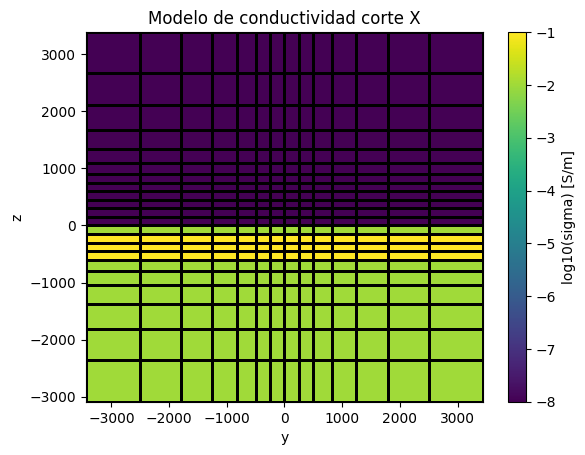

In [ ]:
# 3) Plot del modelo de conductividad 2D
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="X")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte X")
plt.savefig(f"Modelo_Toy4_CorteX.png", dpi=300)
plt.show()

In [4]:
# 4) Guardar malla y modelo

np.save("model_Toy4_MT.npy", sigma)
mesh.save("mesh_Toy4_MT.json")


'c:\\Users\\crist\\Desktop\\Operador - SimPEG\\Repositorio-V5\\Repositorio-V5\\Models\\mesh_Toy4_MT.json'